In [1]:
import numpy as np
import scipy as sp
import krylov as kr
import ham_generator as gen
import matplotlib.pyplot as plt
import networkx as nx

# Real triangle with initial superposition of two sites

$$\ket{\psi_0} = \text{cos}\left(\frac{\theta}{2}\right)\ket{0} + e^{i\varphi}\text{sin}\left(\frac{\theta}{2}\right)\ket{1} $$

$$\ket{\psi_0} = c_0(\theta,\varphi)\ket{E_0} + c_+(\theta,\varphi)\ket{E_+} $$

with: $$ c_0(\theta,\varphi) = \frac{1}{\sqrt{3}}\left (\text{cos}\left(\frac{\theta}{2}\right) + e^{i\varphi}\text{sin}\left(\frac{\theta}{2}\right)\right )  $$ ,

$$c_+(\theta,\varphi) = \sqrt{\frac{2}{3}}\sqrt{1+\text{cos}\left(\frac{\theta}{2}\right)\text{sin}\left(\frac{\theta}{2}\right)\left(\text{cos}(\varphi+2\pi/3)+\text{cos}(\varphi+4\pi/3)  \right)} $$

The only relevant Lanczos coefficients are $ a_0 $ and $ b_1 $, which evaluate to:

\begin{equation}
    a_0(\theta, \phi) = \text{sin}(\theta)\text{cos}(\varphi),
\end{equation}
and
\begin{equation}
    b_1(\theta, \phi) = \sqrt{|c_0|^2(2-a_0)^2+|c_+|^2(1+a_0)^2}
\end{equation}

The infinite time-averaged complexity is:
\begin{equation}
    \bar{C}(\theta, \phi) = \frac{1}{b_1^2}\left ( |c_0|^4(2-a_0)^2 + |c_+|^4(1+a_0)^2 \right)
\end{equation}

In [2]:
#definition of analytical solutions
#C0
def c_0(theta, phi):
    norm = 1./np.sqrt(3)
    c = np.cos(theta/2.)
    s = np.sin(theta/2.)
    phase = np.exp(phi*1.j)
    return norm*(c+phase*s)

#C+
def c_plus(theta, phi):
    norm = np.sqrt(2./3.)
    c = np.cos(theta/2.)
    s = np.sin(theta/2.)
    shift = 2.*np.pi/3.
    c1 = np.cos(phi+shift)
    c2 = np.cos(phi+2*shift)
    body = 1+c*s*(c1+c2)
    return norm*np.sqrt(body)

#a0
def a_0(theta, phi):
    s = np.sin(theta)
    c = np.cos(phi)
    return s*c

#b1
def b_1(theta, phi):
    first = (np.abs(c_0(theta, phi))*(2.-a_0(theta, phi)))**2
    second = (np.abs(c_plus(theta, phi))*(1.+a_0(theta, phi)))**2
    return np.sqrt(first+second)

#complexity
def c_bar(theta, phi):
    return 2*b_1(theta, phi)**2/9


In [3]:
n_thetas = 1000
n_phis = 1000

thetas = np.linspace(start=0.,stop=np.pi, num=n_thetas)
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)

#theta_phis = np.array([[(theta, phi) for phi in phis] for theta in thetas])

a_0s= np.array([[a_0(theta, phi) for theta in thetas] for phi in phis])
#print(a_0s[:,1])

## $a_0$ as a function of $\theta$ and $\phi$

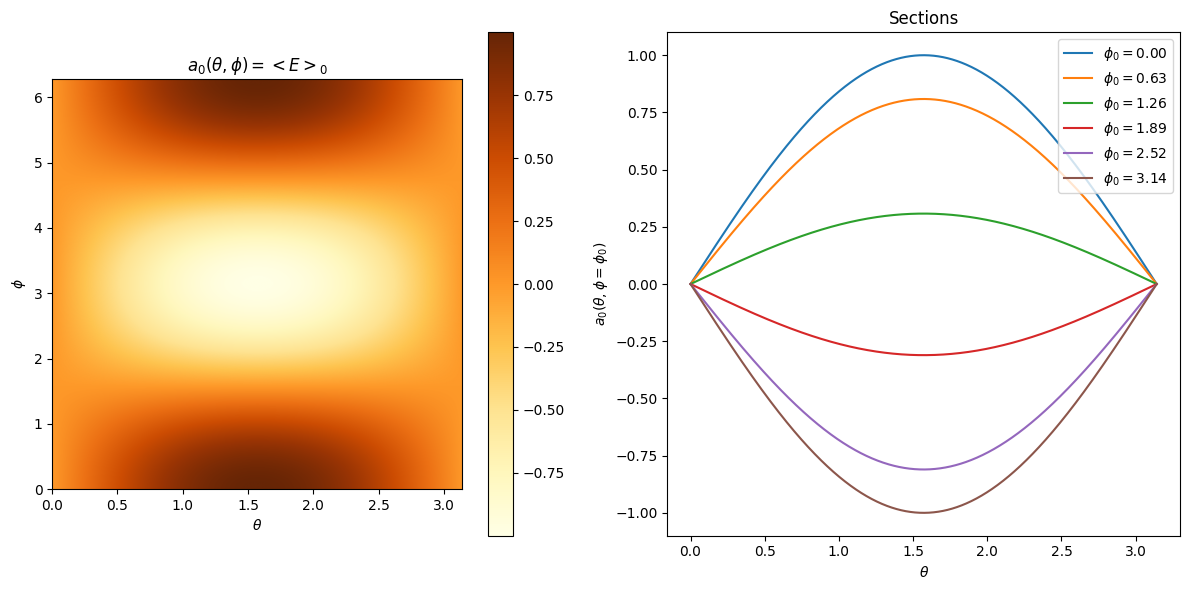

In [4]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

Z = a_0s

im = axx[0].imshow(Z, extent=[thetas[0], thetas[-1], phis[0], phis[-1]], origin='lower', cmap='YlOrBr')
cbr = fig.colorbar(im, ax=axx[0])
axx[0].set_aspect(0.5)
axx[0].set_xlabel(r'$\theta$')
axx[0].set_ylabel(r'$\phi$')
axx[0].set_title(r'$a_0(\theta, \phi)= < E >_0$')

for i in range(6):
    axx[1].plot(thetas, a_0s[100*i,:], label=f"$\phi_0=${format(phis[100*i], '.2f')}")
axx[1].set_xlabel(r'$\theta$')
axx[1].set_ylabel(r'$a_0(\theta, \phi=\phi_0)$')
axx[1].set_title(r'Sections')
axx[1].legend()

plt.show()

## $\bar{C}$ as a function of $\theta$ and $\phi$

\begin{equation}
    \bar{C}(\theta, \phi) = \frac{1}{b_1^2}\left ( |c_0|^4(2-a_0)^2 + |c_+|^4(1+a_0)^2 \right)
\end{equation}

\begin{equation}
    a_0(\theta, \phi) = \text{sin}(\theta)\text{cos}(\varphi)
\end{equation}

In [5]:
n_thetas = 1000
n_phis = 1000

thetas = np.linspace(start=0.,stop=np.pi, num=n_thetas)
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)

#theta_phis = np.array([[(theta, phi) for phi in phis] for theta in thetas])

c_bars= np.array([[c_bar(theta, phi) for theta in thetas] for phi in phis])
#print(a_0s[:,1])

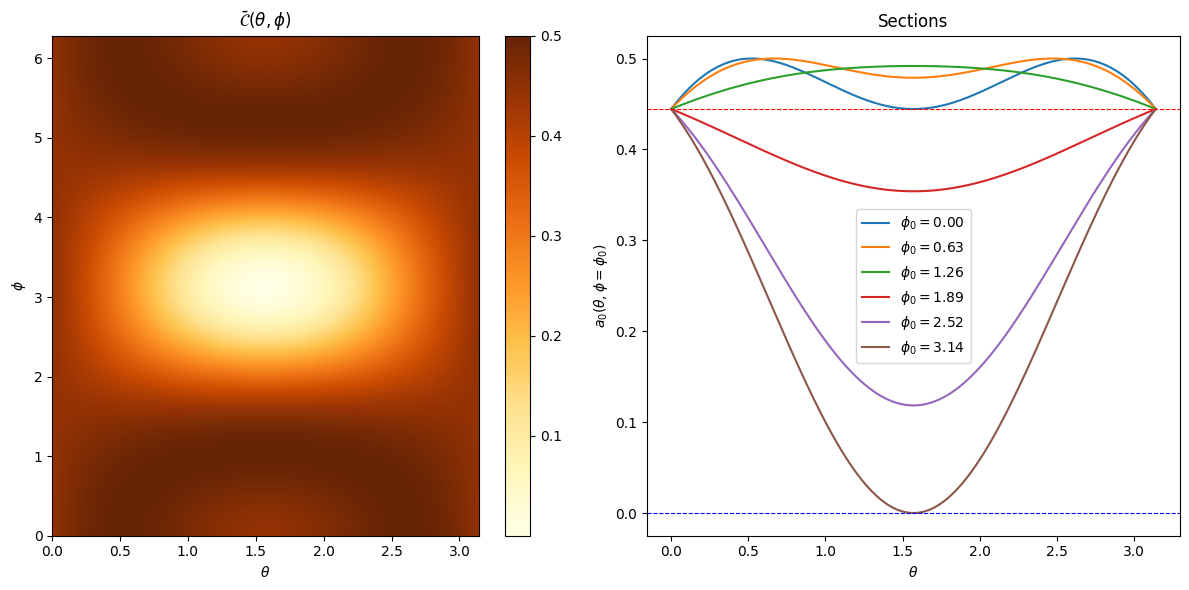

In [6]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

Z = c_bars

im = axx[0].imshow(Z, extent=[thetas[0], thetas[-1], phis[0], phis[-1]], origin='lower', cmap='YlOrBr')
cbr = fig.colorbar(im, ax=axx[0])
axx[0].set_aspect('auto')
axx[0].set_xlabel(r'$\theta$')
axx[0].set_ylabel(r'$\phi$')
axx[0].set_title(r'$\bar{\mathcal{C}}(\theta, \phi)$')

for i in range(6):
    axx[1].plot(thetas, c_bars[100*i,:], label=f"$\phi_0=${format(phis[100*i], '.2f')}")
axx[1].axhline(y=c_bars[0,0], linestyle='--', color='r', linewidth=0.8)
axx[1].axhline(y=0., linestyle='--', color='b', linewidth=0.8)
axx[1].set_xlabel(r'$\theta$')
axx[1].set_ylabel(r'$a_0(\theta, \phi=\phi_0)$')
axx[1].set_title(r'Sections')
axx[1].legend()

plt.show()

# Superposition of ALL sites (general qutrit)

\begin{equation*}
    \ket{\psi_0} = \text{cos}\left ( \frac{\theta_1}{2} \right ) \ket{0} 
    + e^{i\varphi_1} \text{sin}\left ( \frac{\theta_1}{2} \right ) \text{cos}\left ( \frac{\theta_2}{2} \right ) \ket{1}
    + e^{i\varphi_2} \text{sin}\left ( \frac{\theta_1}{2} \right ) \text{sin}\left ( \frac{\theta_2}{2} \right ) \ket{2};
\end{equation*}

\begin{equation*}
    \ket{\psi_0} = \alpha_0 \ket{E_0} + \alpha_+ \ket{E_+}.
\end{equation*}

Notice that $\ket{E_+}$ is different from the one defined for the qubit: its definition is always chosen such that $\ket{\psi_0}$ is orthogonal to the other basis vector of the eigenspace $\ket{E_+}$ belongs to.

The coefficients are:

\begin{equation*}
    \alpha_0 = \frac{1}{\sqrt{3}} \left ( c_1 + s_1c_2 e^{i\varphi_1} + s_1s_2 e^{i\varphi_2 } \right ),
\end{equation*}

   
\begin{align*}
    \alpha_+ = \sqrt{\frac{2}{3}} \sqrt{1 + c_1s_1c_2 f(\varphi_1) +
               c_1s_1s_2 f(\varphi_2) + 
               s_1^2c_2s_2 f(\varphi_1 - \varphi_2) }.
\end{align*}

where $ f(\varphi) = \text{cos}(\varphi+2\pi/3)+\text{cos}(\varphi+4\pi/3) $

From these overlaps, one gets all the interesting quantities:

```math
    a_0 = 2 |\alpha_0|^2 - |\alpha_+|^2,
```
```math
    b_1 = (2-a_0)^2 |\alpha_0|^2 + (1+a_0)^2 |\alpha_+|^2,
``` 
and

```math
    \bar{\mathcal{C}} = \frac{1}{b_1^2}\left ( (2-a_0)^2 |\alpha_0|^4 + (1+a_0)^2 |\alpha_+|^4 \right ).
```

In [12]:
theta_max = np.loadtxt("output/params.out", usecols=1, skiprows=0, max_rows=1, unpack=True)
phi_max = np.loadtxt("output/params.out", usecols=1, skiprows=1, max_rows=1, unpack=True)
n_theta1 = np.loadtxt("output/params.out", dtype=int, usecols=1, skiprows=2, max_rows=1, unpack=True)
n_theta2 = np.loadtxt("output/params.out", dtype=int, usecols=1, skiprows=3, max_rows=1, unpack=True)
n_phi1 = np.loadtxt("output/params.out", dtype=int, usecols=1, skiprows=4, max_rows=1, unpack=True)
n_phi2 = np.loadtxt("output/params.out", dtype=int, usecols=1, skiprows=5, max_rows=1, unpack=True)

In [13]:
theta1s = np.linspace(0, theta_max*(1.-1./n_theta1), n_theta1)
theta2s = np.linspace(0, theta_max*(1.-1./n_theta2), n_theta2)

phi1s = np.linspace(0, phi_max*(1.-1./n_phi1), n_phi1)
phi2s = np.linspace(0, phi_max*(1.-1./n_phi2), n_phi2)

In [14]:
c_bars_tot = np.ndarray(shape=(n_theta1, n_phi1, n_theta2, n_phi2))

temp = np.loadtxt("output/output.out", usecols=4, skiprows=1)

In [15]:
#reshape the vector temp to make it a 4 tensor

for i in range(n_theta1):
    for j in range(n_phi1):
        for k in range(n_theta2):
            for l in range(n_phi2):
                c_bars_tot[i,j,k,l] = temp[i*n_phi1*n_theta2*n_phi2 + j*n_theta2*n_phi2 + k*n_phi2 + l]

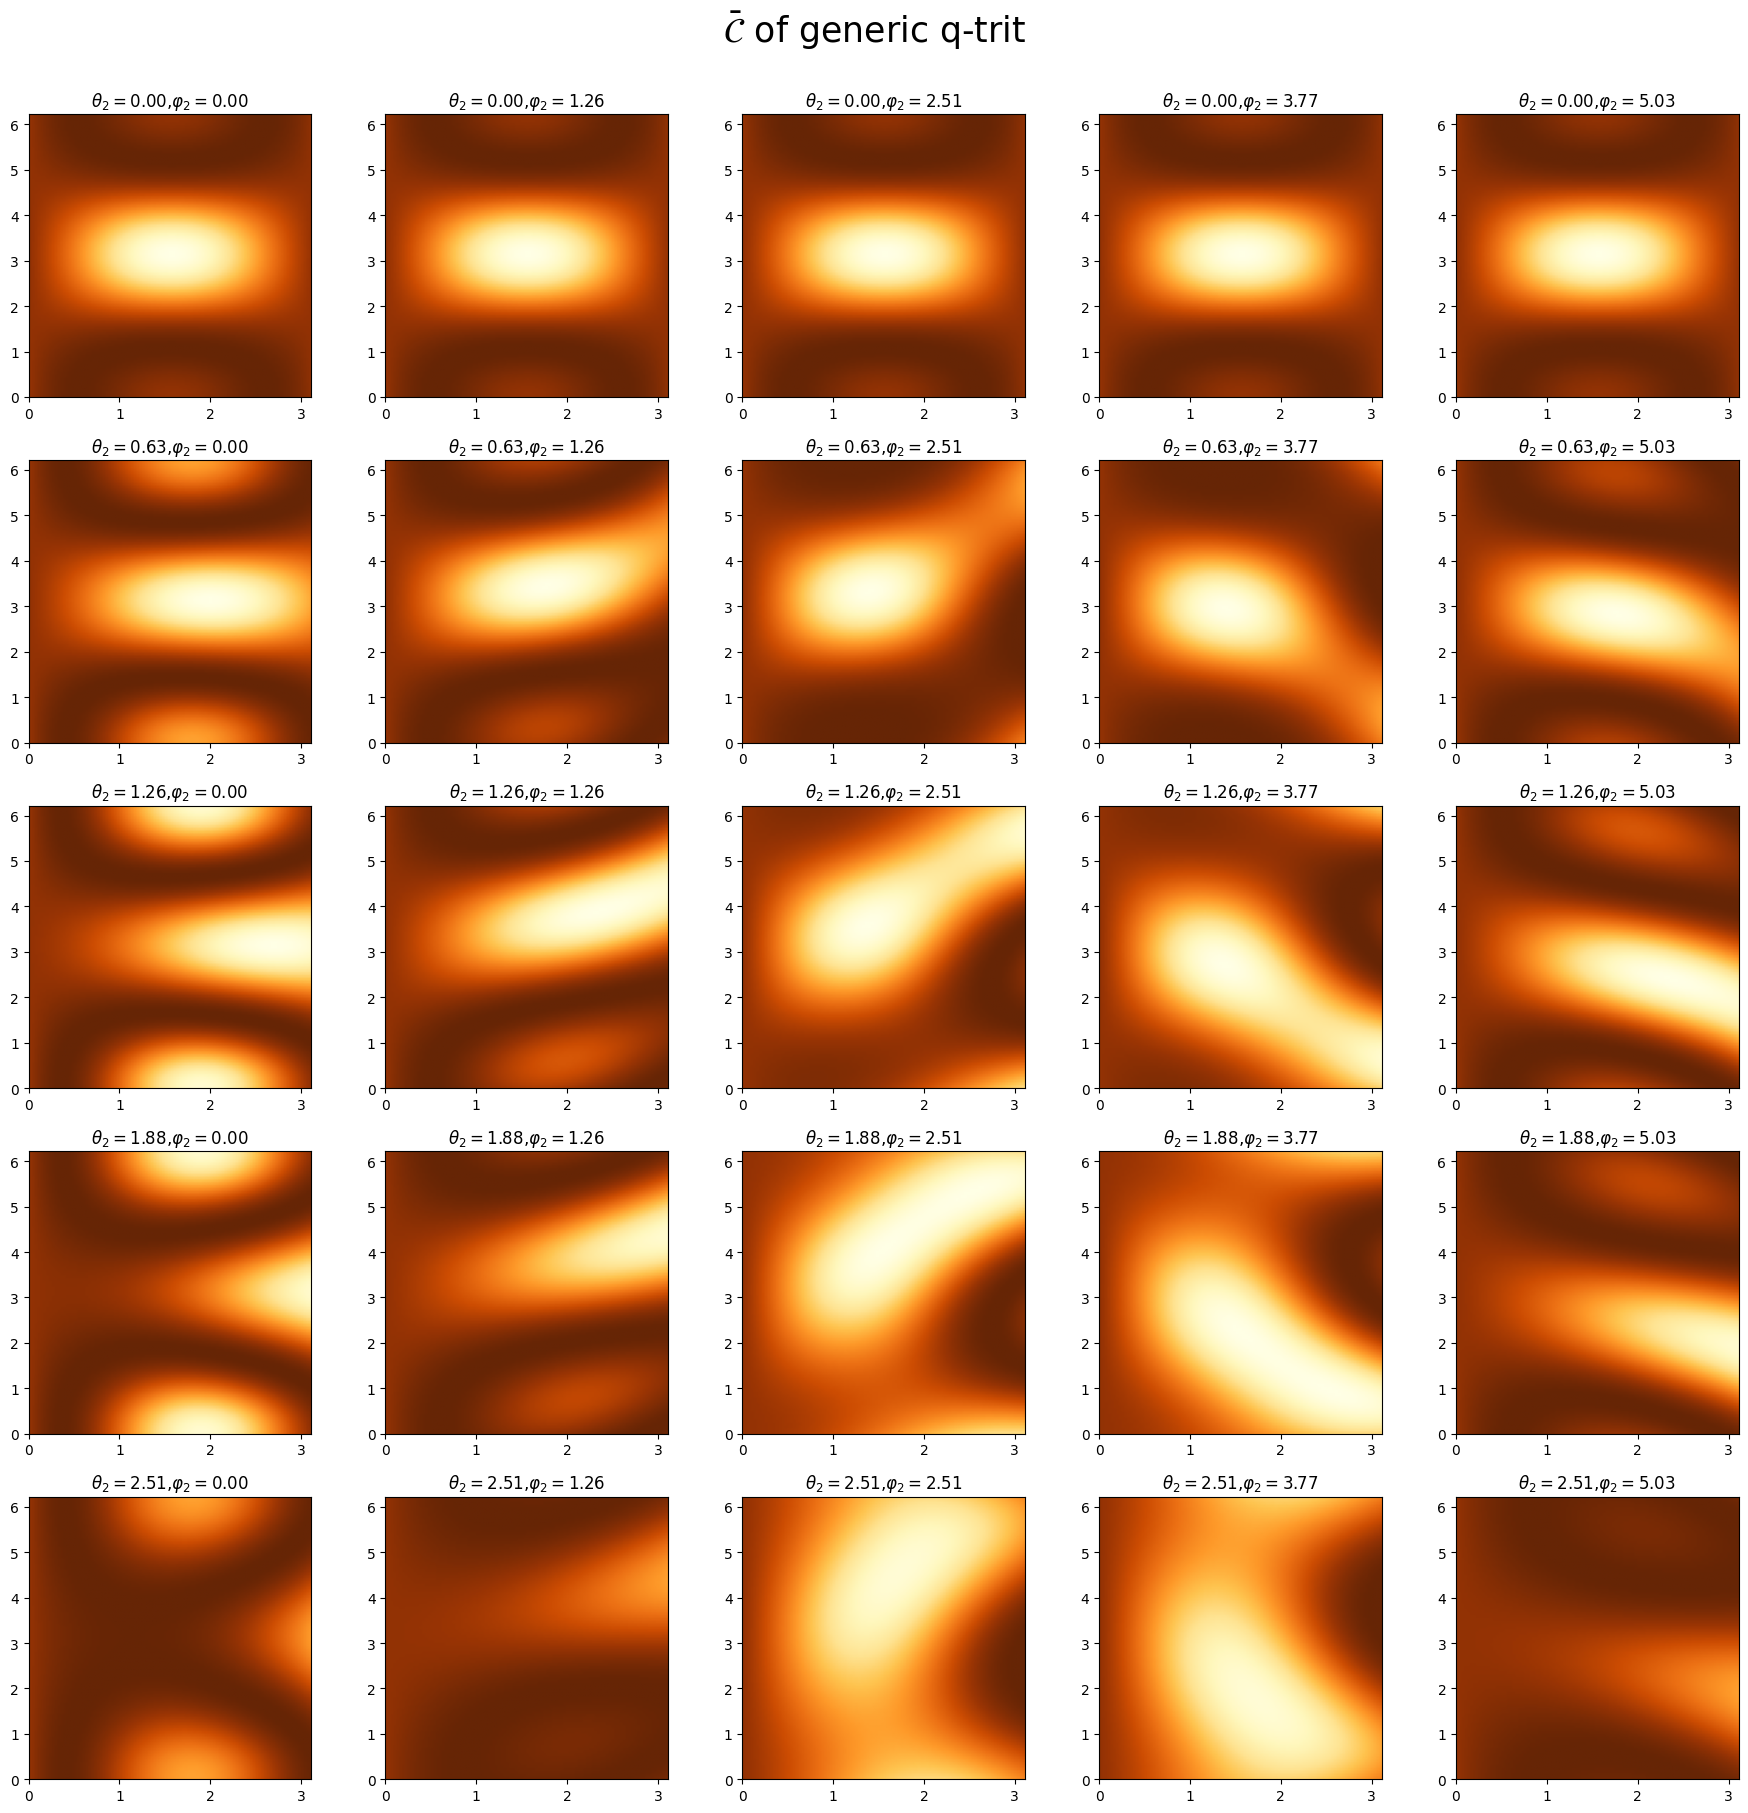

In [16]:
#a 5x5 grid of plots, where figures plot C_bar as a function of theta1 and phi1, and the slices correspond to valyes of theta2 and phi2

fig, axes = plt.subplots(5,5, figsize=(18,18), tight_layout=True)

vmin = c_bars.min()
vmax = c_bars.max()

fig.suptitle(r"$\bar{\mathcal{C}}$ of generic q-trit", fontsize=25, y=1.005)

#fig.subplots_adjust(top=1.1)

for i in range(n_theta2):
    for j in range(n_phi2):
        ax = axes[i][j]
        ax.set_title(r"$\theta_2=$"+f"{format(theta2s[i], '.2f')},"+r"$\varphi_2=$"+f"{format(phi2s[j], '.2f')}")

        Z = c_bars_tot[:,:,i,j].T
        im = ax.imshow(Z, extent=[theta1s[0], theta1s[-1], phi1s[0], phi1s[-1]], origin='lower', cmap='YlOrBr', vmin=vmin, vmax=vmax)
        ax.set_aspect(0.5)

"""
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation= 'horizontal',
    location = "top",
    pad=0.2
)
"""
plt.show()

# States uniformly generated from $\mathbb{C}\textbf{P}^n$

## $\mathbb{C}\textbf{P}^1$

Initial state as superposition of only 2 sites

In [17]:
#not used anymore, just left here for reference
def random_qu_dit(n_points, dim):
    z = np.random.normal(size=(n_points, dim)) + np.random.normal(size=(n_points, dim))*1.j

    #renormalize
    z /= np.linalg.norm(z, axis=1)[:, None]

    #set global phase
    phi_global = np.angle(z[:,0])
    
    for i in range(n_points):
        z[i,:] *= np.exp(-phi_global*1.j)[i]

    return z

In [18]:
n_points_cpp = np.loadtxt("output/qubit_rng.out", usecols=1, dtype=int, max_rows=1, unpack=True)
compl_qubit_cpp = np.loadtxt("output/qubit_rng.out", usecols=0, skiprows=2, unpack=True)

== Distribution moments ==
evalue:  0.3705
stddev:  0.1443


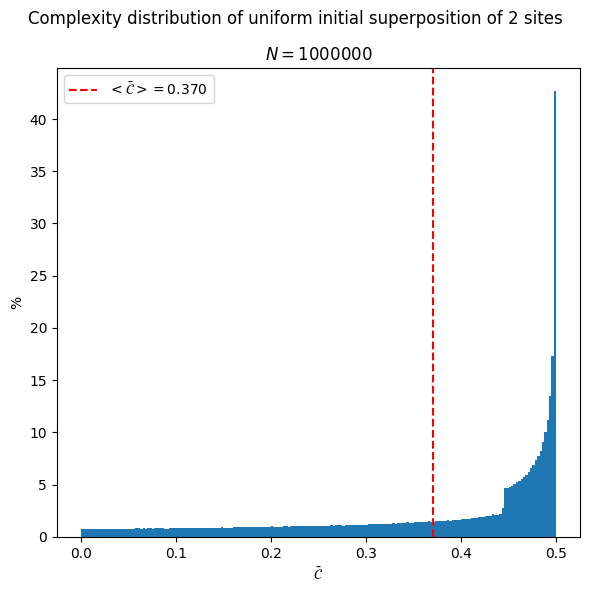

In [19]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

fig.suptitle("Complexity distribution of uniform initial superposition of 2 sites")

axx.set_title(r"$N=$"+f"{n_points_cpp}")

axx.set_xlabel(r"$\bar{\mathcal{C}}$")
axx.set_ylabel(r"%")

axx.hist(compl_qubit_cpp, bins=200, density=True)
axx.axvline(x=np.average(compl_qubit_cpp), label=r"$<\bar{\mathcal{C}}>=$"+f"{format(np.average(compl_qubit_cpp), '.3f')}", linestyle="--", color='r')

axx.legend()

print("== Distribution moments ==")
print("evalue: ", format(np.average(compl_qubit_cpp), '.4f'))
print("stddev: ", format(np.sqrt(np.var(compl_qubit_cpp)), '.4f'))
print(26*"=")

plt.show()


## $\mathbb{C}\textbf{P}^2$

Most general initial state, superposition of all 3 sites

In [20]:
n_points_cpp = np.loadtxt("output/qutrit_rng.out", usecols=1, dtype=int, max_rows=1, unpack=True)
compl_qutrit_cpp = np.loadtxt("output/qutrit_rng.out", usecols=0, skiprows=2, unpack=True)

== Distribution moments ==
evalue:  0.3332
stddev:  0.1491


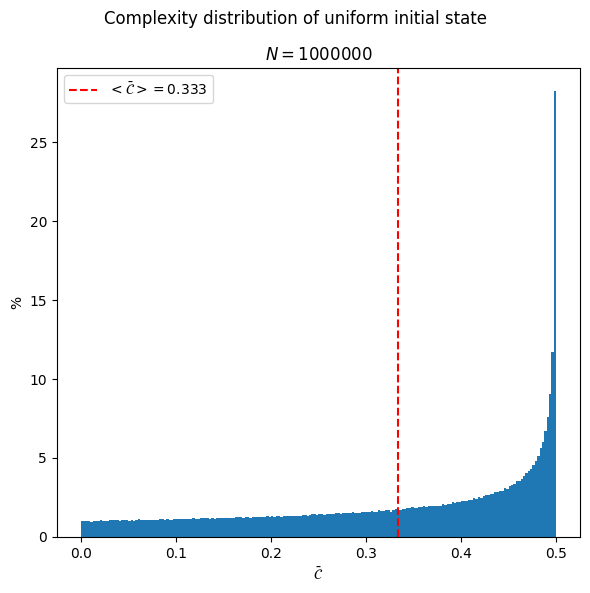

In [21]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

fig.suptitle("Complexity distribution of uniform initial state")

axx.set_title(r"$N=$"+f"{n_points_cpp}")

axx.set_xlabel(r"$\bar{\mathcal{C}}$")
axx.set_ylabel(r"%")

axx.hist(compl_qutrit_cpp, bins=200, density=True)
axx.axvline(x=np.average(compl_qutrit_cpp), label=r"$<\bar{\mathcal{C}}>=$"+f"{format(np.average(compl_qutrit_cpp), '.3f')}", linestyle="--", color='r')

axx.legend()

print("== Distribution moments ==")
print("evalue: ", format(np.average(compl_qutrit_cpp), '.4f'))
print("stddev: ", format(np.sqrt(np.var(compl_qutrit_cpp)), '.4f'))
print(26*"=")

plt.show()

Note: C++ code is very efficient, number of samples can be easily increased by a large amount.